# ISLP Chapter 10 Lab: Deep Learning

**Text:** *An Introduction to Statistical Learning with Applications in Python*, 10.9

This lab fits six models across five data types, building from a single hidden layer up to
convolutional and recurrent architectures:

| Section | Data | Model | Compare against |
|---|---|---|---|
| 10.9.1 | `Hitters` | Single hidden layer (50 units) | OLS, lasso |
| 10.9.2 | MNIST | Two hidden layers (256, 128) | Multinomial logistic regression |
| 10.9.3 | CIFAR100 | CNN, four conv blocks | |
| 10.9.4 | Own images | Pretrained ResNet50 | |
| 10.9.5 | IMDb | Two dense layers on bag-of-words | Lasso logistic regression |
| 10.9.6 | IMDb, `NYSE` | LSTM, RNN, non-linear AR | Linear AR model |

The recurring theme is worth holding onto: in almost every comparison here, a well-tuned
classical method lands close to the neural network. Deep learning wins decisively on the image
data, where the architecture encodes real structure about the problem.

---

## ⚠️ Before running

**This notebook is slow and downloads data.** Read this first.

- **Extra packages required**, not shipped with ISLP:
  `pip install torch torchvision torchmetrics torchinfo pytorch_lightning`
- **Downloads**: MNIST (~110 MB), CIFAR100 (~170 MB), ResNet50 weights (~100 MB),
  IMDb (via ISLP). These land in `data/` on first run.
- **Runtimes** on CPU: MNIST ≈ 4 min, CIFAR100 **10+ min**, IMDb LSTM several minutes,
  NYSE RNN (200 epochs) several minutes. The book's timings are from an Apple M1 Pro.
- **§10.9.4 needs two manual downloads**: `book_images.zip` from the data section of
  statlearning.com, and `imagenet_class_index.json`. Both must sit in the working directory.
  That section will fail without them.
- **Run the notebook top to bottom.** Each section ends with a `del(...)` cleanup cell that
  removes names later cells might otherwise reuse, and §10.9.6 depends on variables created in
  §10.9.5. Out-of-order execution will produce `NameError`s.

If you only need one section for an assignment, run Setup plus that section, and skip the
cleanup cell at the end of the preceding one.

---
## Setup

### Standard imports

In [63]:
import numpy as np, pandas as pd
from matplotlib.pyplot import subplots
from sklearn.linear_model import \
     (LinearRegression,
      LogisticRegression,
      Lasso)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from ISLP import load_data
from ISLP.models import ModelSpec as MS
from sklearn.model_selection import \
     (train_test_split,
      GridSearchCV)

### Torch imports

`nn` holds the layer types and the base `Module` class. `RMSprop` is the optimizer —
a variant of SGD that adapts the step size per parameter. `TensorDataset` pairs feature and
response tensors into something a data loader can iterate.

In [64]:
import torch
from torch import nn
from torch.optim import RMSprop
from torch.utils.data import TensorDataset

Helper packages: `torchmetrics` supplies metric objects that accumulate correctly across
mini-batches, and `torchinfo.summary` prints layer shapes and parameter counts — the quickest
way to check an architecture does what you intended before spending minutes training it.

In [65]:
from torchmetrics import (MeanAbsoluteError,
                          R2Score)
from torchinfo import summary
from torchvision.io import read_image

`pytorch_lightning` wraps the training loop. Written in raw torch, every model here would need
an explicit loop over epochs and batches with manual `zero_grad()`, `backward()` and `step()`
calls. Lightning's `Trainer` handles that boilerplate.

In [66]:
from pytorch_lightning import Trainer
from pytorch_lightning.loggers import CSVLogger

### Reproducibility

`seed_everything` seeds Python, numpy and torch at once. The import path moved between Lightning
versions the book's `pytorch_lightning.utilities.seed` path fails on current releases, so the
fallback below covers both.

`use_deterministic_algorithms` forces deterministic kernels where they exist. `warn_only=True`
means operations without a deterministic implementation warn instead of raising. Even so, exact
reproducibility across different machines and GPU setups is not guaranteed expect your numbers
to differ slightly from the book's.

In [67]:
try:
    from pytorch_lightning.utilities.seed import seed_everything
except ImportError:                      # newer pytorch_lightning
    from pytorch_lightning import seed_everything

seed_everything(0, workers=True)
torch.use_deterministic_algorithms(True, warn_only=True)

Seed set to 0


In [68]:
from torchvision.datasets import MNIST, CIFAR100
from torchvision.models import (resnet50,
                                ResNet50_Weights)
from torchvision.transforms import (Resize,
                                    Normalize,
                                    CenterCrop,
                                    ToTensor)

### ISLP helpers

`SimpleDataModule` bundles train/validation/test loaders; `SimpleModule` supplies the
training/validation/test step logic with a sensible loss for the task; `ErrorTracker` accumulates
predictions across mini-batches so metrics are computed over the whole validation or test set
rather than averaged per batch which is not the same thing when batches differ in size.

In [69]:
from ISLP.torch import (SimpleDataModule,
                        SimpleModule,
                        ErrorTracker,
                        rec_num_workers)

In [70]:
from ISLP.torch.imdb import (load_lookup,
                             load_tensor,
                             load_sparse,
                             load_sequential)

In [71]:
from glob import glob
import json

---
## 10.9.1 Single Layer Network on `Hitters`

A network with one hidden layer of $K$ units computes

$$f(X) = \beta_0 + \sum_{k=1}^{K} \beta_k \, g\!\left(w_{k0} + \sum_{j=1}^{p} w_{kj} X_j\right),$$

with $g$ the ReLU activation $g(z) = \max(0, z)$. The non-linearity is essential: without it,
a composition of linear maps is just another linear map, and depth buys nothing.

The comparison here 263 observations, 19 predictors is deliberately unfavourable to deep
learning. A network with 1,051 parameters fitted to 175 training observations should not be
expected to beat least squares, and mostly doesn't.

In [72]:
Hitters = load_data('Hitters').dropna()
n = Hitters.shape[0]
n

263

Mean absolute error is the yardstick:
$\text{MAE}(y,\hat y) = \frac 1n \sum_i |y_i - \hat y_i|$. It is less sensitive to a few large
errors than MSE, which matters for salary data with a long right tail.

In [73]:
model = MS(Hitters.columns.drop('Salary'), intercept=False)
X = model.fit_transform(Hitters).to_numpy()
Y = Hitters['Salary'].to_numpy()

In [74]:
(X_train,
 X_test,
 Y_train,
 Y_test) = train_test_split(X,
                            Y,
                            test_size=1/3,
                            random_state=1)

### Linear baselines

Least squares first. Test MAE lands near 259.7.

In [75]:
hit_lm = LinearRegression().fit(X_train, Y_train)
Yhat_test = hit_lm.predict(X_test)
np.abs(Yhat_test - Y_test).mean()

np.float64(259.7152883314631)

The lasso needs scaled features the penalty treats all coefficients alike, so a predictor
measured in thousands would be penalized far less in practice than one measured in units. The
`Pipeline` ensures the scaler is fitted inside each CV fold, never on the full training set.

`GridSearchCV` is scored by MAE rather than the MSE the specialized lasso solvers assume, which
is why this is done manually rather than with `LassoCV`.

In [76]:
scaler = StandardScaler(with_mean=True, with_std=True)
lasso = Lasso(warm_start=True, max_iter=30000)
standard_lasso = Pipeline(steps=[('scaler', scaler),
                                 ('lasso', lasso)])

The $\lambda$ grid runs from `lam_max` the smallest penalty giving an all-zero solution,
equal to the largest absolute inner product between any predictor and the centered response
down to 1% of it, 100 values log-spaced. Starting at the value that zeroes everything guarantees
the grid spans the whole useful range rather than being guessed.

Note the scaling is applied *before* computing `lam_max`, since the scale of the predictors
determines what counts as a large penalty.

In [77]:
X_s = scaler.fit_transform(X_train)
n = X_s.shape[0]
lam_max = np.fabs(X_s.T.dot(Y_train - Y_train.mean())).max() / n
param_grid = {'alpha': np.exp(np.linspace(0, np.log(0.01), 100))
                       * lam_max}

In [78]:
cv = KFold(10,
           shuffle=True,
           random_state=1)
grid = GridSearchCV(lasso,
                    param_grid,
                    cv=cv,
                    scoring='neg_mean_absolute_error')
grid.fit(X_train, Y_train);

Test MAE around 257.2 essentially tied with least squares. The book adds a caveat worth
repeating: these figures move substantially with the train/test seed. A difference of 2.5 MAE on
88 test observations is noise, not a finding. Try `random_state=2` above and rerun to see for
yourself.

In [79]:
trained_lasso = grid.best_estimator_
Yhat_test = trained_lasso.predict(X_test)
np.fabs(Yhat_test - Y_test).mean()

np.float64(257.23820107995107)

### Specifying a network

A torch model is a class inheriting from `nn.Module` with two methods:

- `__init__` create and attach the layers. The `super().__init__()` call is **mandatory**;
  `nn.Module.__init__` sets up the parameter registry, and without it torch cannot find the
  weights to train.
- `forward` describe how an input flows through those layers.

The architecture: 19 inputs → 50 hidden units → ReLU → 40% dropout → 1 output.

**Dropout** randomly zeroes 40% of hidden units during each training step, forcing the network to
avoid relying on any single unit. It is a regularizer, and it is active *only* during training
`eval()` turns it off, which is why that call matters before predicting.

Parameter count: $50 \times 19 + 50$ for the first layer, $50 + 1$ for the output, giving 1,051.
That is six times the number of training observations.

In [80]:
class HittersModel(nn.Module):

    def __init__(self, input_size):
        super(HittersModel, self).__init__()
        self.flatten = nn.Flatten()
        self.sequential = nn.Sequential(
            nn.Linear(input_size, 50),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(50, 1))

    def forward(self, x):
        x = self.flatten(x)
        return torch.flatten(self.sequential(x))

In [81]:
hit_model = HittersModel(X.shape[1])

`summary()` confirms the shapes and the 1,051 total. Run this before training any network
a shape mismatch caught here costs seconds, the same mistake caught after a CIFAR run costs
ten minutes.

In [82]:
summary(hit_model,
        input_size=X_train.shape,
        col_names=['input_size',
                   'output_size',
                   'num_params'])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
HittersModel                             [175, 19]                 [175]                     --
├─Flatten: 1-1                           [175, 19]                 [175, 19]                 --
├─Sequential: 1-2                        [175, 19]                 [175, 1]                  --
│    └─Linear: 2-1                       [175, 19]                 [175, 50]                 1,000
│    └─ReLU: 2-2                         [175, 50]                 [175, 50]                 --
│    └─Dropout: 2-3                      [175, 50]                 [175, 50]                 --
│    └─Linear: 2-4                       [175, 50]                 [175, 1]                  51
Total params: 1,051
Trainable params: 1,051
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.18
Input size (MB): 0.01
Forward/backward pass size (MB): 0.07
Params size (MB): 0.00
Estimated Total Size (MB): 0.09

### Data in torch form

Torch works in 32-bit floats by default, while numpy defaults to 64-bit, hence the explicit
`astype(np.float32)`. Skipping it produces a dtype error rather than a silent wrong answer, but
it is a frequent first stumble.

In [83]:
X_train_t = torch.tensor(X_train.astype(np.float32))
Y_train_t = torch.tensor(Y_train.astype(np.float32))
hit_train = TensorDataset(X_train_t, Y_train_t)

In [84]:
X_test_t = torch.tensor(X_test.astype(np.float32))
Y_test_t = torch.tensor(Y_test.astype(np.float32))
hit_test = TensorDataset(X_test_t, Y_test_t)

In [85]:
max_num_workers = rec_num_workers()
max_num_workers

8

The data module handles batching and shuffling. Here the test set doubles as validation data
(`validation=hit_test`), which is convenient for watching the test curve during training but
means the validation curve is **not** an honest held-out estimate anything tuned by looking at
it, early stopping in particular, would be selecting on the test set. The book flags this same
point again in §10.9.6.

`validation` also accepts a float (fraction of training data) or an int (number of observations),
which is the cleaner option when a real test set must stay untouched.

In [86]:
hit_dm = SimpleDataModule(hit_train,
                          hit_test,
                          batch_size=32,
                          num_workers=min(4, max_num_workers),
                          validation=hit_test)

`SimpleModule.regression()` uses squared-error loss; MAE is tracked alongside as a reported
metric. Loss and metric need not agree the model optimizes MSE while we judge it on MAE.

In [87]:
hit_module = SimpleModule.regression(hit_model,
                                     metrics={'mae':MeanAbsoluteError()})

In [88]:
hit_logger = CSVLogger('logs', name='hitters')

### Training

Each SGD step uses a random batch of 32 observations to estimate the gradient. With $n = 175$,
one epoch is $175/32 \approx 5.5$ steps, so 50 epochs is roughly 275 gradient updates very few
by deep learning standards, appropriate for a dataset this small.

Each `fit()` call writes to a **new** subdirectory under `logs/hitters`. Re-running this cell and
then reading the log picks up the latest run, not an average.

In [89]:
hit_trainer = Trainer(deterministic=True,
                      max_epochs=50,
                      log_every_n_steps=5,
                      logger=hit_logger,
                      callbacks=[ErrorTracker()])
hit_trainer.fit(hit_module, datamodule=hit_dm)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name  | Type         | Params | Mode  | FLOPs
-------------------------------------------------------
0 | model | HittersModel | 1.1 K  | train | 0    
1 | loss  | MSELoss      | 0      | train | 0    
-------------------------------------------------------
1.1 K     Trainable params
0         Non-trainable params
1.1 K     Total params
0.004     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/mnt/master_program/semester3/data_mining/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 49: 100%|██████████| 6/6 [00:00<00:00, 92.56it/s, v_num=2]            

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 6/6 [00:00<00:00, 85.04it/s, v_num=2]


Test MAE around 229.5 — better than both linear models' ~258. A genuine win, though on 88 test
observations and one split, so the honest reading is "competitive", not "superior".

In [90]:
hit_trainer.test(hit_module, datamodule=hit_dm)

Testing DataLoader 0: 100%|██████████| 3/3 [00:00<00:00, 233.85it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss             103304.8515625
        test_mae            224.26962280273438
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 103304.8515625, 'test_mae': 224.26962280273438}]

In [91]:
hit_results = pd.read_csv(hit_logger.experiment.metrics_file_path)
hit_results.head()

,epoch,step,test_loss,test_mae,train_loss,train_mae_epoch,train_mae_step,valid_loss,valid_mae
0,0,4,NaN,NaN,NaN,NaN,321.665314,NaN,NaN
1,0,5,NaN,NaN,NaN,NaN,NaN,144056.406250,237.444290
2,0,5,NaN,NaN,814513.375,562.054321,NaN,NaN,NaN
3,1,9,NaN,NaN,NaN,NaN,196.664551,NaN,NaN
4,1,11,NaN,NaN,NaN,NaN,NaN,133880.890625,234.720749


A reusable plotting helper for the learning curves, used in every section below.

In [92]:
def summary_plot(results,
                 ax,
                 col='loss',
                 valid_legend='Validation',
                 training_legend='Training',
                 ylabel='Loss',
                 fontsize=20):
    for (column,
         color,
         label) in zip([f'train_{col}_epoch',
                        f'valid_{col}'],
                       ['black',
                        'red'],
                       [training_legend,
                        valid_legend]):
        results.plot(x='epoch',
                     y=column,
                     label=label,
                     marker='o',
                     color=color,
                     ax=ax)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    return ax

The learning curve is the main diagnostic for any network. Training MAE falling while validation
MAE flattens or rises means overfitting, and the epoch where validation bottoms out is where
early stopping would cut.

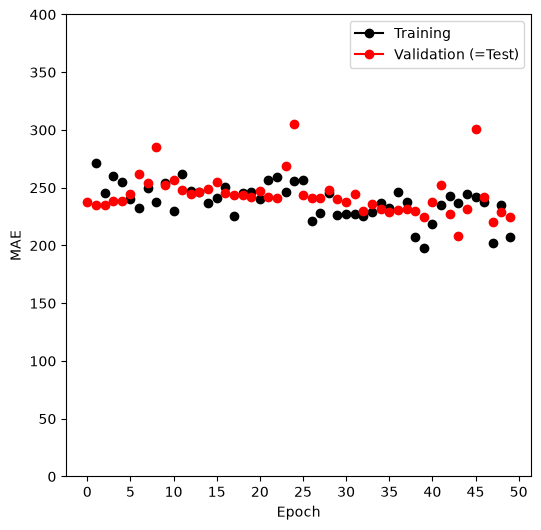

In [93]:
fig, ax = subplots(1, 1, figsize=(6, 6))
ax = summary_plot(hit_results,
                  ax,
                  col='mae',
                  ylabel='MAE',
                  valid_legend='Validation (=Test)')
ax.set_ylim([0, 400])
ax.set_xticks(np.linspace(0, 50, 11).astype(int));

Predicting directly requires `eval()` first that switches dropout off. Forgetting it means
predictions are made with 40% of hidden units randomly zeroed, which gives different answers on
every call. The result below matches the trainer's test MAE exactly, confirming the model is in
evaluation mode.

In [94]:
hit_model.eval()
preds = hit_module(X_test_t)
torch.abs(Y_test_t - preds).mean()

tensor(224.2696, grad_fn=<MeanBackward0>)

### Cleanup

The data module spawned worker processes that stay alive while references exist. Deleting the
objects lets them be collected. **This cell removes names used above** — skip it if you plan to
revisit this section.

In [95]:
del(Hitters,
    hit_model, hit_dm,
    hit_logger,
    hit_test, hit_train,
    X, Y,
    X_test, X_train,
    Y_test, Y_train,
    X_test_t, Y_test_t,
    hit_trainer, hit_module)

---
## 10.9.2 Multilayer Network on MNIST

60,000 training and 10,000 test images of handwritten digits, 28×28 grayscale.

Scale matters here for the same reason it matters for ridge and lasso: gradient descent on
inputs ranging 0–255 takes wildly different effective step sizes than on inputs in [0, 1].
`ToTensor()` handles both the rescaling to the unit interval and the axis reordering torch
expects.

**First run downloads ~110 MB into `data/MNIST`.**

In [96]:
(mnist_train,
 mnist_test) = [MNIST(root='data',
                      train=train,
                      download=True,
                      transform=ToTensor())
                for train in [True, False]]
mnist_train

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

Here 20% of the *training* images are held out for validation, leaving the 10,000 test images
genuinely untouched until the end — the cleaner setup compared to the `Hitters` section.

In [97]:
mnist_dm = SimpleDataModule(mnist_train,
                            mnist_test,
                            validation=0.2,
                            num_workers=max_num_workers,
                            batch_size=256)

Inspecting a batch's shape before building the model is a habit worth keeping. `[256, 1, 28, 28]`
reads as batch × channels × height × width; the `1` is the single grayscale channel, and becomes
`3` for the RGB images of CIFAR100.

In [98]:
for idx, (X_ ,Y_) in enumerate(mnist_dm.train_dataloader()):
    print('X: ', X_.shape)
    print('Y: ', Y_.shape)
    if idx >= 1:
        break

X:  torch.Size([256, 1, 28, 28])
Y:  torch.Size([256])
X:  torch.Size([256, 1, 28, 28])
Y:  torch.Size([256])


Two hidden layers: 784 → 256 (ReLU, 40% dropout) → 128 (ReLU, 30% dropout) → 10.

Note the output layer has 10 units and **no softmax**. The cross-entropy loss in torch applies
the softmax internally for numerical stability, so adding one here would apply it twice and
degrade training. The outputs are logits, not probabilities.

Also note the composition style: `layer1` and `layer2` are themselves `Sequential` modules, then
composed into `_forward`. Modules nest freely, which is what makes the CNN in the next section
straightforward to write.

In [99]:
class MNISTModel(nn.Module):

    def __init__(self):
        super(MNISTModel, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256),
            nn.ReLU(),
            nn.Dropout(0.4))
        self.layer2 = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3))
        self._forward = nn.Sequential(
            self.layer1,
            self.layer2,
            nn.Linear(128, 10))

    def forward(self, x):
        return self._forward(x)

In [100]:
mnist_model = MNISTModel()

In [101]:
mnist_model(X_).size()

torch.Size([256, 10])

235,146 parameters — but now with 48,000 training images, a far healthier ratio than the
`Hitters` model had.

In [102]:
summary(mnist_model,
        input_data=X_,
        col_names=['input_size',
                   'output_size',
                   'num_params'])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
MNISTModel                               [256, 1, 28, 28]          [256, 10]                 --
├─Sequential: 1-1                        [256, 1, 28, 28]          [256, 10]                 --
│    └─Sequential: 2-1                   [256, 1, 28, 28]          [256, 256]                --
│    │    └─Flatten: 3-1                 [256, 1, 28, 28]          [256, 784]                --
│    │    └─Linear: 3-2                  [256, 784]                [256, 256]                200,960
│    │    └─ReLU: 3-3                    [256, 256]                [256, 256]                --
│    │    └─Dropout: 3-4                 [256, 256]                [256, 256]                --
│    └─Sequential: 2-2                   [256, 256]                [256, 128]                --
│    │    └─Linear: 3-5                  [256, 256]                [256, 128]                32,896
│    │    └─ReLU: 3-6     

`SimpleModule.classification()` switches the loss to cross-entropy and tracks accuracy by default.

In [103]:
# Pass num_classes=10 for the MNIST dataset
mnist_module = SimpleModule.classification(mnist_model, num_classes=10) 
mnist_logger = CSVLogger('logs', name='MNIST')


**Slow cell — roughly 4 minutes on CPU.** 48,000 training images in batches of 256 is 188
gradient steps per epoch, times 30 epochs.

In [104]:
mnist_trainer = Trainer(deterministic=True,
                        max_epochs=30,
                        logger=mnist_logger,
                        callbacks=[ErrorTracker()])
mnist_trainer.fit(mnist_module,
                  datamodule=mnist_dm)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name  | Type             | Params | Mode  | FLOPs
-----------------------------------------------------------
0 | model | MNISTModel       | 235 K  | train | 0    
1 | loss  | CrossEntropyLoss | 0      | train | 0    
-----------------------------------------------------------
235 K     Trainable params
0         Non-trainable params
235 K     Total params
0.941     Total estimated model params size (MB)
13        Modules in train mode
0         Modules in eval mode
0         Tota

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/mnt/master_program/semester3/data_mining/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 29: 100%|██████████| 188/188 [00:04<00:00, 40.16it/s, v_num=2]        

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 188/188 [00:04<00:00, 39.96it/s, v_num=2]


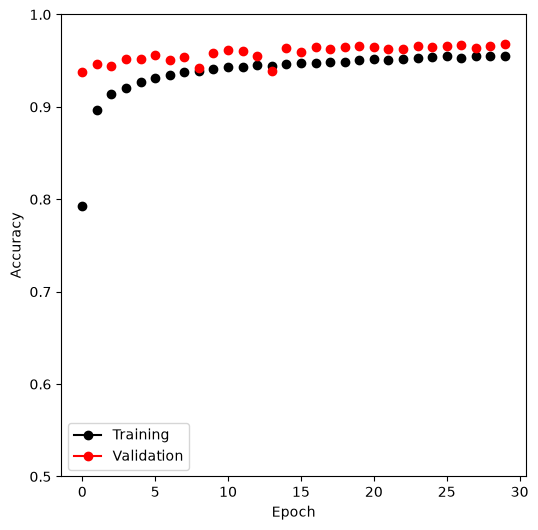

In [105]:
mnist_results = pd.read_csv(mnist_logger.experiment.metrics_file_path)
fig, ax = subplots(1, 1, figsize=(6, 6))
summary_plot(mnist_results,
             ax,
             col='accuracy',
             ylabel='Accuracy')
ax.set_ylim([0.5, 1])
ax.set_ylabel('Accuracy')
ax.set_xticks(np.linspace(0, 30, 7).astype(int));

About 97% test accuracy.

In [106]:
mnist_trainer.test(mnist_module,
                   datamodule=mnist_dm)

/mnt/master_program/semester3/data_mining/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing DataLoader 0: 100%|██████████| 40/40 [00:00<00:00, 120.57it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      test_accuracy         0.9686999917030334
        test_loss           0.15795908868312836
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.15795908868312836, 'test_accuracy': 0.9686999917030334}]

### The baseline: multinomial logistic regression

Strip out the hidden layers and a neural network *is* multinomial logistic regression — input
layer straight to output layer, softmax on top. That is a useful thing to see stated in code:
these methods are points on a continuum, not separate families.

This could equally be fitted with sklearn's `LogisticRegression`; doing it in torch makes the
architectural relationship explicit.

In [107]:
class MNIST_MLR(nn.Module):
    def __init__(self):
        super(MNIST_MLR, self).__init__()
        self.linear = nn.Sequential(nn.Flatten(),
                                    nn.Linear(784, 10))

    def forward(self, x):
        return self.linear(x)

mlr_model = MNIST_MLR()

# Add num_classes=10
mlr_module = SimpleModule.classification(mlr_model, num_classes=10)
mlr_logger = CSVLogger('logs', name='MNIST_MLR')


In [108]:
mlr_trainer = Trainer(deterministic=True,
                      max_epochs=30,
                      callbacks=[ErrorTracker()])
mlr_trainer.fit(mlr_module, datamodule=mnist_dm)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name  | Type             | Params | Mode  | FLOPs
-----------------------------------------------------------
0 | model | MNIST_MLR        | 7.9 K  | train | 0    
1 | loss  | CrossEntropyLoss | 0      | train | 0    
-----------------------------------------------------------
7.9 K     Trainable params
0         Non-trainable params
7.9 K     Total params
0.031     Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode
0         Tota

Epoch 29: 100%|██████████| 188/188 [00:04<00:00, 41.11it/s, v_num=2]        

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 188/188 [00:04<00:00, 41.05it/s, v_num=2]


About 92% — from a model with no hidden layers at all. The two hidden layers buy roughly 5
percentage points, which is real (it more than halves the error rate) but far less dramatic than
the gap between "deep learning" and "logistic regression" usually sounds. Worth remembering when
reading accuracy claims.

In [109]:
mlr_trainer.test(mlr_module,
                 datamodule=mnist_dm)

Testing DataLoader 0: 100%|██████████| 40/40 [00:00<00:00, 125.71it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      test_accuracy         0.9240999817848206
        test_loss           0.31868264079093933
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.31868264079093933, 'test_accuracy': 0.9240999817848206}]

In [110]:
del(mnist_test,
    mnist_train,
    mnist_model,
    mnist_dm,
    mnist_trainer,
    mnist_module,
    mnist_results,
    mlr_model,
    mlr_module,
    mlr_trainer)

---
## 10.9.3 Convolutional Neural Networks

CIFAR100: 50,000 training images, 32×32 RGB, 100 classes.

A dense layer on flattened pixels throws away everything about spatial structure — it has no idea
that two adjacent pixels are related. A CNN encodes that structure directly:

- **Convolution** slides a small filter across the image, computing a weighted sum at each
  position. The same weights are reused everywhere (*parameter sharing*), so a feature learned in
  one corner is detected anywhere. A 3×3 filter over 3 channels needs 28 parameters regardless of
  image size.
- **ReLU** applies the non-linearity.
- **Max-pooling** takes the maximum over each 2×2 block, halving both dimensions. This gives
  a degree of translation invariance and cuts computation.

Stacking these blocks builds a hierarchy: edges, then textures, then object parts.

**First run downloads ~170 MB.**

In [111]:
(cifar_train,
 cifar_test) = [CIFAR100(root="data",
                         train=train,
                         download=True)
                for train in [True, False]]

In [112]:
transform = ToTensor()
cifar_train_X = torch.stack([transform(x) for x in
                             cifar_train.data])
cifar_test_X = torch.stack([transform(x) for x in
                            cifar_test.data])
cifar_train = TensorDataset(cifar_train_X,
                            torch.tensor(cifar_train.targets))
cifar_test = TensorDataset(cifar_test_X,
                           torch.tensor(cifar_test.targets))

In [113]:
cifar_dm = SimpleDataModule(cifar_train,
                            cifar_test,
                            validation=0.2,
                            num_workers=max_num_workers,
                            batch_size=128)

In [114]:
for idx, (X_ ,Y_) in enumerate(cifar_dm.train_dataloader()):
    print('X: ', X_.shape)
    print('Y: ', Y_.shape)
    if idx >= 1:
        break

X:  torch.Size([128, 3, 32, 32])
Y:  torch.Size([128])
X:  torch.Size([128, 3, 32, 32])
Y:  torch.Size([128])


Looking at the images before modeling is always worth the cell. `np.transpose(..., [1,2,0])`
reorders from torch's channels-first layout to the channels-last layout `imshow` expects — get
this wrong and you get a colorful mess rather than an error.

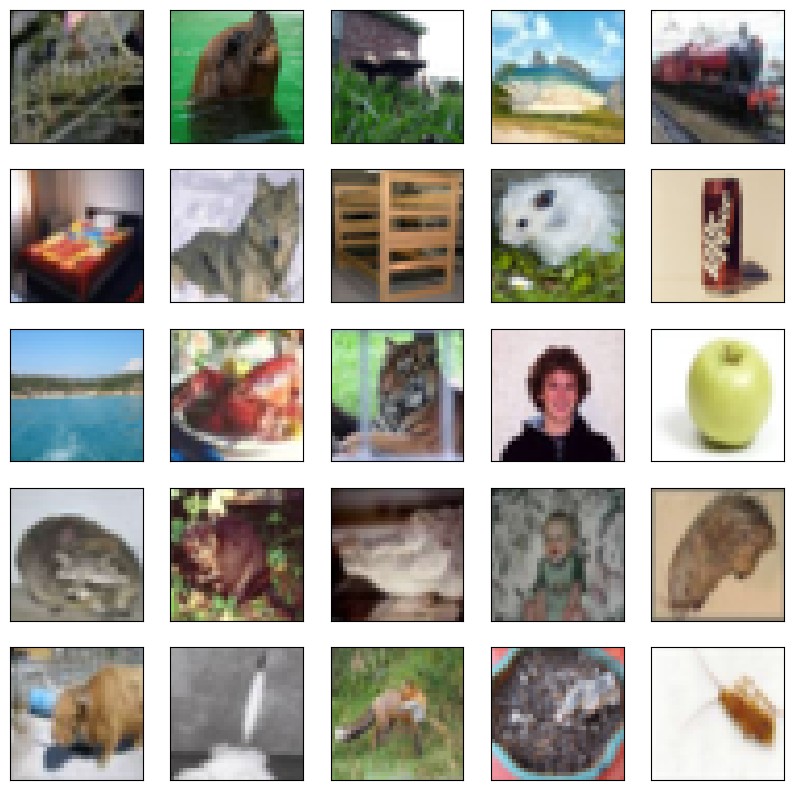

In [115]:
fig, axes = subplots(5, 5, figsize=(10,10))
rng = np.random.default_rng(4)
indices = rng.choice(np.arange(len(cifar_train)), 25,
                     replace=False).reshape((5,5))
for i in range(5):
    for j in range(5):
        idx = indices[i,j]
        axes[i,j].imshow(np.transpose(cifar_train[idx][0],
                                      [1,2,0]),
                         interpolation=None)
        axes[i,j].set_xticks([])
        axes[i,j].set_yticks([])

One conv block as a reusable module. `padding='same'` keeps the spatial dimensions unchanged
through the convolution, so all the shrinking happens in the pooling step — which makes the
dimension arithmetic easy to follow.

Defining custom modules like this is the point of torch's design: `BuildingBlock` can now be used
exactly like a built-in layer.

In [116]:
class BuildingBlock(nn.Module):

    def __init__(self,
                 in_channels,
                 out_channels):

        super(BuildingBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels=in_channels,
                              out_channels=out_channels,
                              kernel_size=(3,3),
                              padding='same')
        self.activation = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=(2,2))

    def forward(self, x):
        return self.pool(self.activation(self.conv(x)))

Four blocks, doubling channels while halving spatial dimensions each time: 32×32 → 16×16 → 8×8 →
4×4 → 2×2, with channels going 3 → 32 → 64 → 128 → 256. The trade is spatial detail for feature
depth. After the last block, 256 channels of 2×2 flatten to 1,024 values, then dropout → 512 →
100 classes.

Where the parameters sit is instructive: the four convolution layers together use about 388,000,
while the single dense layer from 1,024 to 512 uses 524,800 on its own. Convolution is
parameter-cheap; dense layers are expensive.

In [117]:
class CIFARModel(nn.Module):

    def __init__(self):
        super(CIFARModel, self).__init__()
        sizes = [(3,32),
                 (32,64),
                 (64,128),
                 (128,256)]
        self.conv = nn.Sequential(*[BuildingBlock(in_, out_)
                                    for in_, out_ in sizes])

        self.output = nn.Sequential(nn.Dropout(0.5),
                                    nn.Linear(2*2*256, 512),
                                    nn.ReLU(),
                                    nn.Linear(512, 100))

    def forward(self, x):
        val = self.conv(x)
        val = torch.flatten(val, start_dim=1)
        return self.output(val)

In [118]:
cifar_model = CIFARModel()
summary(cifar_model,
        input_data=X_,
        col_names=['input_size',
                   'output_size',
                   'num_params'])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
CIFARModel                               [128, 3, 32, 32]          [128, 100]                --
├─Sequential: 1-1                        [128, 3, 32, 32]          [128, 256, 2, 2]          --
│    └─BuildingBlock: 2-1                [128, 3, 32, 32]          [128, 32, 16, 16]         --
│    │    └─Conv2d: 3-1                  [128, 3, 32, 32]          [128, 32, 32, 32]         896
│    │    └─ReLU: 3-2                    [128, 32, 32, 32]         [128, 32, 32, 32]         --
│    │    └─MaxPool2d: 3-3               [128, 32, 32, 32]         [128, 32, 16, 16]         --
│    └─BuildingBlock: 2-2                [128, 32, 16, 16]         [128, 64, 8, 8]           --
│    │    └─Conv2d: 3-4                  [128, 32, 16, 16]         [128, 64, 16, 16]         18,496
│    │    └─ReLU: 3-5                    [128, 64, 16, 16]         [128, 64, 16, 16]         --
│    │    └─MaxPool2d: 3-6    

A custom optimizer with learning rate 0.001 rather than the default 0.01. The learning rate is
the single most consequential hyperparameter in training: too large and the loss oscillates or
diverges, too small and training crawls. If a network refuses to learn, this is the first thing
to change.

In [119]:
cifar_optimizer = RMSprop(cifar_model.parameters(), lr=0.001)

# CIFAR100 has 100 classes, not 10. num_classes must match the
# size of the model's output layer, nn.Linear(512, 100)
cifar_module = SimpleModule.classification(cifar_model,
                                           num_classes=100,
                                           optimizer=cifar_optimizer)
cifar_logger = CSVLogger('logs', name='CIFAR100')

**Slowest cell in the notebook — 10 minutes or more on CPU.**

In [120]:
cifar_trainer = Trainer(deterministic=True,
                        max_epochs=30,
                        logger=cifar_logger,
                        callbacks=[ErrorTracker()])
cifar_trainer.fit(cifar_module,
                  datamodule=cifar_dm)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name  | Type             | Params | Mode  | FLOPs
-----------------------------------------------------------
0 | model | CIFARModel       | 964 K  | train | 0    
1 | loss  | CrossEntropyLoss | 0      | train | 0    
-----------------------------------------------------------
964 K     Trainable params
0         Non-trainable params
964 K     Total params
3.858     Total estimated model params size (MB)
24        Modules in train mode
0         Modules in eval mode
0         Tota

Epoch 29: 100%|██████████| 313/313 [00:46<00:00,  6.68it/s, v_num=2]        

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 313/313 [00:46<00:00,  6.66it/s, v_num=2]


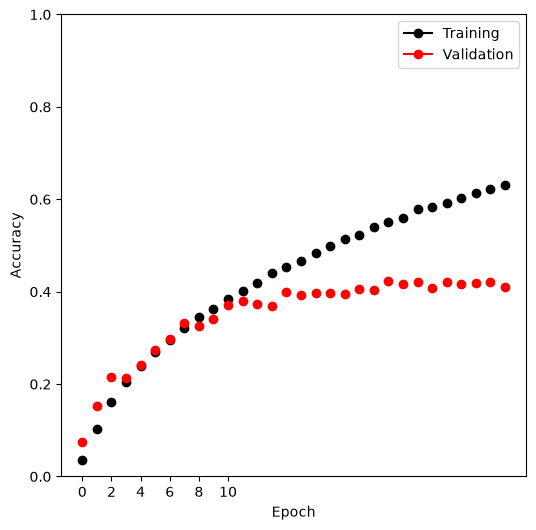

In [121]:
log_path = cifar_logger.experiment.metrics_file_path
cifar_results = pd.read_csv(log_path)
fig, ax = subplots(1, 1, figsize=(6, 6))
summary_plot(cifar_results,
             ax,
             col='accuracy',
             ylabel='Accuracy')
ax.set_xticks(np.linspace(0, 10, 6).astype(int))
ax.set_ylabel('Accuracy')
ax.set_ylim([0, 1]);

About 42% test accuracy. Judge that against the right baseline: random guessing on 100 classes
gives 1%, so 42% is substantial. But published results on CIFAR100 reach around 75%, and closing
that gap takes architecture work, heavier regularization, data augmentation, and considerably
more training. Getting a reasonable result quickly and getting a competitive one are very
different amounts of effort.

In [122]:
cifar_trainer.test(cifar_module,
                   datamodule=cifar_dm)

/mnt/master_program/semester3/data_mining/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Testing DataLoader 0: 100%|██████████| 79/79 [00:05<00:00, 14.03it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      test_accuracy         0.4108999967575073
        test_loss           2.4681897163391113
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 2.4681897163391113, 'test_accuracy': 0.4108999967575073}]

### Hardware acceleration

`accelerator='mps'` uses Apple Metal on M-series Macs, for roughly 2–3× speedup. `'gpu'` is the
equivalent for CUDA. Metrics must be moved to the same device as the data, hence the `.to('mps')`
calls.

The whole block is wrapped in `try/except` so it silently does nothing on hardware without MPS.
Bare `except:` is poor practice in general — it swallows every error including typos — but here
it keeps the notebook portable.

In [123]:
try:
    for name, metric in cifar_module.metrics.items():
        cifar_module.metrics[name] = metric.to('mps')
    cifar_trainer_mps = Trainer(accelerator='mps',
                                deterministic=True,
                                max_epochs=30)
    cifar_trainer_mps.fit(cifar_module,
                          datamodule=cifar_dm)
    cifar_trainer_mps.test(cifar_module,
                           datamodule=cifar_dm)
except:
    pass

---
## 10.9.4 Using Pretrained CNN Models

Training a competitive image classifier from scratch needs enormous data and compute. The
practical alternative is **transfer learning**: take a network already trained on ImageNet
(1.2 million images, 1,000 classes) and apply it directly, or fine-tune it on your own data.

> **This section needs two manual downloads.** Get `book_images.zip` from the data section of
> [statlearning.com](https://www.statlearning.com) and unzip it here, and download
> `imagenet_class_index.json`. Without both, the cells below raise errors. Skip this section if
> you don't need it.

The preprocessing must match exactly what ResNet50 was trained with — resize to 232, center-crop
to 224, scale to [0,1], then normalize with ImageNet's channel means and standard deviations.
Those specific numbers are not arbitrary; using different ones degrades predictions badly, and
this mismatch is the most common transfer-learning bug.

### Fetching the two required assets

This section needs files that are not bundled with any package: the six photographs in
`book_images/`, and `imagenet_class_index.json` for decoding class indices into names.

The cell below checks for both and tries to download whatever is missing. If the download fails
(no network, or the URL has moved), it prints exactly what to fetch by hand and where to put it.
Get `book_images.zip` from the data section of https://www.statlearning.com and unzip it beside
this notebook.

You can also point `IMAGE_DIR` at a folder of your own JPEGs. ResNet50 classifies any natural
image, so the section works with your own photos, only the predicted labels change.

In [124]:
import os, zipfile, urllib.request

IMAGE_DIR = 'book_images'
LABELS_FILE = 'imagenet_class_index.json'

BOOK_IMAGES_URL = 'https://www.statlearning.com/s/book_images.zip'
LABELS_URL = ('https://s3.amazonaws.com/deep-learning-models/'
              'image-models/imagenet_class_index.json')


def _try_download(url, dest):
    try:
        urllib.request.urlretrieve(url, dest)
        return True
    except Exception as e:
        print(f'  download failed: {type(e).__name__}: {e}')
        return False


# --- the images
if not (os.path.isdir(IMAGE_DIR) and os.listdir(IMAGE_DIR)):
    print(f'{IMAGE_DIR}/ is missing or empty. Attempting download...')
    if _try_download(BOOK_IMAGES_URL, 'book_images.zip'):
        with zipfile.ZipFile('book_images.zip') as z:
            z.extractall('.')
        print('  unzipped.')
    else:
        print('  MANUAL STEP: download book_images.zip from the data section of')
        print('  https://www.statlearning.com and unzip it next to this notebook,')
        print(f'  or set IMAGE_DIR to a folder of your own .jpg files.')

# --- the label lookup
if not os.path.exists(LABELS_FILE):
    print(f'{LABELS_FILE} is missing. Attempting download...')
    if _try_download(LABELS_URL, LABELS_FILE):
        print('  done.')
    else:
        print(f'  MANUAL STEP: download {LABELS_URL}')
        print(f'  and save it next to this notebook as {LABELS_FILE}')

have_images = os.path.isdir(IMAGE_DIR) and bool(
    [f for f in os.listdir(IMAGE_DIR) if not f.startswith('.')])
have_labels = os.path.exists(LABELS_FILE)
print(f'\nimages ready: {have_images}   labels ready: {have_labels}')

book_images/ is missing or empty. Attempting download...
  unzipped.
imagenet_class_index.json is missing. Attempting download...
  done.

images ready: True   labels ready: True


In [125]:
resize = Resize((232,232))
crop = CenterCrop(224)
normalize = Normalize([0.485,0.456,0.406],
                      [0.229,0.224,0.225])

imgfiles = sorted([f for f in glob(f'{IMAGE_DIR}/*')
                   if not os.path.basename(f).startswith('.')])

if not imgfiles:
    raise FileNotFoundError(
        f"No images found in '{IMAGE_DIR}/'. Run the setup cell above, or "
        f"point IMAGE_DIR at a folder containing .jpg files. Without images "
        f"torch.stack receives an empty list and raises "
        f"'stack expects a non-empty TensorList'.")

print(f'{len(imgfiles)} images:', [os.path.basename(f) for f in imgfiles])

imgs = torch.stack([torch.div(crop(resize(read_image(f))), 255)
                    for f in imgfiles])
imgs = normalize(imgs)
imgs.size()

6 images: ['flamingo.jpg', 'hawk.jpg', 'hawk_cropped.jpeg', 'huey.jpg', 'kitty.jpg', 'weaver.jpg']


torch.Size([6, 3, 224, 224])

In [126]:
resnet_model = resnet50(weights=ResNet50_Weights.DEFAULT)
summary(resnet_model,
        input_data=imgs,
        col_names=['input_size',
                   'output_size',
                   'num_params'])

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/tatakae/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:18<00:00, 5.43MB/s]


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
ResNet                                   [6, 3, 224, 224]          [6, 1000]                 --
├─Conv2d: 1-1                            [6, 3, 224, 224]          [6, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [6, 64, 112, 112]         [6, 64, 112, 112]         128
├─ReLU: 1-3                              [6, 64, 112, 112]         [6, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [6, 64, 112, 112]         [6, 64, 56, 56]           --
├─Sequential: 1-5                        [6, 64, 56, 56]           [6, 256, 56, 56]          --
│    └─Bottleneck: 2-1                   [6, 64, 56, 56]           [6, 256, 56, 56]          --
│    │    └─Conv2d: 3-1                  [6, 64, 56, 56]           [6, 64, 56, 56]           4,096
│    │    └─BatchNorm2d: 3-2             [6, 64, 56, 56]           [6, 64, 56, 56]           128
│    │    └─ReLU: 3-3      

`eval()` again — essential here, since ResNet50 contains batch-normalization layers that behave
differently in training and evaluation mode.

In [127]:
resnet_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [128]:
img_preds = resnet_model(imgs)

The network outputs logits, so a softmax converts them to probabilities. `detach()` removes the
tensor from the autograd graph — without it, numpy conversion fails because torch is still
tracking gradients it would need for backpropagation.

In [129]:
img_probs = np.exp(np.asarray(img_preds.detach()))
img_probs /= img_probs.sum(1)[:,None]

In [130]:
labs = json.load(open('imagenet_class_index.json'))
class_labels = pd.DataFrame([(int(k), v[1]) for k, v in
                             labs.items()],
                            columns=['idx', 'label'])
class_labels = class_labels.set_index('idx')
class_labels = class_labels.sort_index()

The top-3 predictions per image are worth reading carefully. The flamingo comes back at 59%
confidence. The others are far less certain — the Cape Weaver is called a jacamar at 29%, and the
hawk-by-a-fountain gets `great_grey_owl` first with `fountain` third, which suggests the model is
partly responding to the background rather than the bird.

Confident *and* wrong is the pattern to watch for. A softmax always produces probabilities
summing to one, including for classes the network has never seen — it cannot say "I don't know".

In [131]:
for i, imgfile in enumerate(imgfiles):
    img_df = class_labels.copy()
    img_df['prob'] = img_probs[i]
    img_df = img_df.sort_values(by='prob', ascending=False)[:3]
    print(f'Image: {imgfile}')
    print(img_df.reset_index().drop(columns=['idx']))

Image: book_images/flamingo.jpg
            label      prob
0        flamingo  0.609514
1       spoonbill  0.013586
2  American_egret  0.002132
Image: book_images/hawk.jpg
            label      prob
0            kite  0.184717
1           robin  0.084018
2  great_grey_owl  0.061267
Image: book_images/hawk_cropped.jpeg
            label      prob
0            kite  0.453834
1  great_grey_owl  0.015914
2             jay  0.012210
Image: book_images/huey.jpg
             label      prob
0            Lhasa  0.260317
1         Shih-Tzu  0.097196
2  Tibetan_terrier  0.032819
Image: book_images/kitty.jpg
         label      prob
0  Persian_cat  0.163070
1        tabby  0.074143
2    tiger_cat  0.042578
Image: book_images/weaver.jpg
      label      prob
0   jacamar  0.297500
1     macaw  0.068107
2  lorikeet  0.051104


In [132]:
del(cifar_test,
    cifar_train,
    cifar_dm,
    cifar_module,
    cifar_logger,
    cifar_optimizer,
    cifar_trainer)

---
## 10.9.5 IMDb Document Classification

25,000 movie reviews labeled positive or negative, using a 10,000-word dictionary. Three
representations are provided:

- `load_tensor()` — sparse binary bag-of-words for torch
- `load_sparse()` — sparse matrix for sklearn (needed for the lasso comparison)
- `load_sequential()` — padded word-index sequences preserving order, for the RNN in §10.9.6

The first two discard word order entirely; only the third keeps it. Comparing them shows how much
order actually contributes.

In [133]:
(imdb_seq_train,
 imdb_seq_test) = load_sequential(root='data/IMDB')
padded_sample = np.asarray(imdb_seq_train.tensors[0][0])
sample_review = padded_sample[padded_sample > 0][:12]
sample_review[:12]

RemoteDisconnected: Remote end closed connection without response

Short reviews are padded at the front with zeros to a fixed length, hence filtering on `> 0`.
Decoding the integers through the lookup shows a real review — always confirm the encoding does
what you think before training on it.

In [ ]:
lookup = load_lookup(root='data/IMDB')
' '.join(lookup[i] for i in sample_review)

The bag-of-words matrix has a 1 in entry (i, j) when word j appears in review i. Over 98% zeros —
which is why a sparse representation is essential; dense would be 25,000 × 10,000 floats.

In [ ]:
max_num_workers=10
(imdb_train,
 imdb_test) = load_tensor(root='data/IMDB')
imdb_dm = SimpleDataModule(imdb_train,
                           imdb_test,
                           validation=2000,
                           num_workers=min(6, max_num_workers),
                           batch_size=512)

A modest network: 10,000 inputs → 16 → 16 → 1. Note the single output unit with no sigmoid —
as with cross-entropy earlier, the binary loss applies it internally.

The `forward` method here loops over a list of layers rather than using `nn.Sequential`, which is
equivalent but shows that `forward` is just ordinary Python. That flexibility is what allows the
skip connections and branching found in more complex architectures.

In [ ]:
class IMDBModel(nn.Module):

    def __init__(self, input_size):
        super(IMDBModel, self).__init__()
        self.dense1 = nn.Linear(input_size, 16)
        self.activation = nn.ReLU()
        self.dense2 = nn.Linear(16, 16)
        self.output = nn.Linear(16, 1)

    def forward(self, x):
        val = x
        for _map in [self.dense1,
                     self.activation,
                     self.dense2,
                     self.activation,
                     self.output]:
            val = _map(val)
        return torch.flatten(val)

In [ ]:
imdb_model = IMDBModel(imdb_test.tensors[0].size()[1])
summary(imdb_model,
        input_size=imdb_test.tensors[0].size(),
        col_names=['input_size',
                   'output_size',
                   'num_params'])

In [ ]:
imdb_optimizer = RMSprop(imdb_model.parameters(), lr=0.001)
imdb_module = SimpleModule.binary_classification(
                  imdb_model,
                  optimizer=imdb_optimizer)

In [ ]:
imdb_logger = CSVLogger('logs', name='IMDB')
imdb_trainer = Trainer(deterministic=True,
                       max_epochs=30,
                       logger=imdb_logger,
                       callbacks=[ErrorTracker()])
imdb_trainer.fit(imdb_module,
                 datamodule=imdb_dm)

About 86% test accuracy. Hold that number — the lasso is next.

In [ ]:
test_results = imdb_trainer.test(imdb_module, datamodule=imdb_dm)
test_results

### Comparison to the lasso

Lasso logistic regression on the same bag-of-words features. In sklearn the regularization
parameter `C` is the **inverse** of $\lambda$, so a small `C` means heavy penalization —
easy to get backwards.

`warm_start=True` initializes each fit from the previous solution, which makes computing the
whole path of 50 values far faster than 50 independent fits (about 40 seconds total).

In [ ]:
((X_train, Y_train),
 (X_valid, Y_valid),
 (X_test, Y_test)) = load_sparse(validation=2000,
                                 random_state=0,
                                 root='data/IMDB')

In [ ]:
lam_max = np.abs(X_train.T * (Y_train - Y_train.mean())).max()
lam_val = lam_max * np.exp(np.linspace(np.log(1),
                                       np.log(1e-4), 50))

In [ ]:
logit = LogisticRegression(penalty='l1',
                           C=1/lam_max,
                           solver='liblinear',
                           warm_start=True,
                           fit_intercept=True)

In [ ]:
coefs = []
intercepts = []

for l in lam_val:
    logit.C = 1/l
    logit.fit(X_train, Y_train)
    coefs.append(logit.coef_.copy())
    intercepts.append(logit.intercept_)

In [ ]:
coefs = np.squeeze(coefs)
intercepts = np.squeeze(intercepts)

`%%capture` must be the **first line** of the cell — it suppresses the half-finished figure so it
isn't displayed twice, since the next cell adds the second panel.

In [ ]:
%%capture
fig, axes = subplots(1, 2, figsize=(16, 8), sharey=True)
for ((X_, Y_),
     data_,
     color) in zip([(X_train, Y_train),
                    (X_valid, Y_valid),
                    (X_test, Y_test)],
                   ['Training', 'Validation', 'Test'],
                   ['black', 'red', 'blue']):
    linpred_ = X_ * coefs.T + intercepts[None,:]
    label_ = np.array(linpred_ > 0)
    accuracy_ = np.array([np.mean(Y_ == l) for l in label_.T])
    axes[0].plot(-np.log(lam_val / X_train.shape[0]),
                 accuracy_,
                 '.--',
                 color=color,
                 markersize=13,
                 linewidth=2,
                 label=data_)
axes[0].legend()
axes[0].set_xlabel(r'$-\log(\lambda)$', fontsize=20)
axes[0].set_ylabel('Accuracy', fontsize=20)

The composed figure is the honest summary of this section. The lasso peaks near 0.88; the network
reaches about 0.86 (the dashed horizontal line). **A linear model with one tuning parameter
matches or beats a neural network here.**

Both left and right panels also show the same overfitting story: training accuracy climbing while
validation and test accuracy flatten and then decline.

In [ ]:
imdb_results = pd.read_csv(imdb_logger.experiment.metrics_file_path)
summary_plot(imdb_results,
             axes[1],
             col='accuracy',
             ylabel='Accuracy')
axes[1].set_xticks(np.linspace(0, 30, 7).astype(int))
axes[1].set_ylabel('Accuracy', fontsize=20)
axes[1].set_xlabel('Epoch', fontsize=20)
axes[1].set_ylim([0.5, 1]);
axes[1].axhline(test_results[0]['test_accuracy'],
                color='blue',
                linestyle='--',
                linewidth=3)
fig

Note this cleanup keeps `X_test` — §10.9.6 uses its shape to size the embedding layer.

In [ ]:
del(imdb_model,
    imdb_trainer,
    imdb_logger,
    imdb_dm,
    imdb_train,
    imdb_test)

---
## 10.9.6 Recurrent Neural Networks

### Sequential models for document classification

Bag-of-words treats "not good at all" and "good" as sharing a feature. An RNN reads the sequence
in order, carrying a hidden state $A_\ell$ updated at each word:

$$A_\ell = g(W A_{\ell-1} + U x_\ell + b).$$

The same weights are applied at every position — parameter sharing across time, analogous to the
convolution sharing weights across space.

An **LSTM** adds gates that control what the hidden state keeps and forgets, which lets it hold
information over longer spans than a plain RNN, where gradients vanish.

Documents are fixed at 500 words: longer reviews keep the last 500, shorter ones are padded at
the front.

In [ ]:
imdb_seq_dm = SimpleDataModule(imdb_seq_train,
                               imdb_seq_test,
                               validation=2000,
                               batch_size=300,
                               num_workers=min(6, max_num_workers)
                               )

The **embedding** layer is the key idea. One-hot encoding would represent each word as a
10,003-dimensional vector, all orthogonal — so "excellent" and "superb" would be as unrelated as
"excellent" and "the". The embedding maps each word to a 32-dimensional dense vector, *learned
during training*, so related words can end up near each other.

Mechanically, it is a $10{,}003 \times 32$ lookup table indexed by word integer — never an actual
matrix multiplication against a one-hot vector.

`val[:,-1]` in `forward` takes the LSTM output at the **final** time step, i.e. the state after
reading the whole review, and maps it to a single logit.

Note the ordering dependency: `X_test` below comes from the `load_sparse` call in §10.9.5.

In [ ]:
class LSTMModel(nn.Module):

    def __init__(self, input_size):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(input_size, 32)
        self.lstm = nn.LSTM(input_size=32,
                            hidden_size=32,
                            batch_first=True)
        self.dense = nn.Linear(32, 1)

    def forward(self, x):
        val, (h_n, c_n) = self.lstm(self.embedding(x))
        return torch.flatten(self.dense(val[:,-1]))

Of 328,577 total parameters, 320,096 sit in the embedding ($10{,}003 \times 32$) and only 8,448
in the LSTM itself. Most of the model's capacity is the word representation, not the sequential
machinery.

In [ ]:
lstm_model = LSTMModel(X_test.shape[-1])
summary(lstm_model,
        input_data=imdb_seq_train.tensors[0][:10],
        col_names=['input_size',
                   'output_size',
                   'num_params'])

In [ ]:
lstm_module = SimpleModule.binary_classification(lstm_model)
lstm_logger = CSVLogger('logs', name='IMDB_LSTM')

**Slow cell — several minutes.** RNNs process 500 time steps sequentially per review, so they
parallelize poorly compared to dense or convolutional layers.

In [ ]:
lstm_trainer = Trainer(deterministic=True,
                       max_epochs=20,
                       logger=lstm_logger,
                       callbacks=[ErrorTracker()])
lstm_trainer.fit(lstm_module,
                 datamodule=imdb_seq_dm)

About 85% — slightly *below* both the bag-of-words network (86%) and the lasso (88%), for
considerably more compute.

That deserves stating plainly rather than explaining away: on this dataset, with this
architecture and this amount of training, word order did not pay for itself. Sentiment
classification apparently rests mostly on which words appear. State-of-the-art results on IMDb do
exceed this, but they come from much larger pretrained language models, not from an LSTM of this
size.

In [ ]:
lstm_trainer.test(lstm_module, datamodule=imdb_seq_dm)

In [ ]:
lstm_results = pd.read_csv(lstm_logger.experiment.metrics_file_path)
fig, ax = subplots(1, 1, figsize=(6, 6))
summary_plot(lstm_results,
             ax,
             col='accuracy',
             ylabel='Accuracy')
ax.set_xticks(np.linspace(0, 20, 5).astype(int))
ax.set_ylabel('Accuracy')
ax.set_ylim([0.5, 1])

In [ ]:
del(lstm_model,
    lstm_trainer,
    lstm_logger,
    imdb_seq_dm,
    imdb_seq_train,
    imdb_seq_test)

### Time series prediction

The `NYSE` data holds daily returns, log volume and log volatility. The task: predict
`log_volume` from the previous five days of all three series — an autoregressive problem.

Standardizing first puts all three series on a common scale.

In [ ]:
NYSE = load_data('NYSE')
cols = ['DJ_return', 'log_volume', 'log_volatility']
X = pd.DataFrame(StandardScaler(
                     with_mean=True,
                     with_std=True).fit_transform(NYSE[cols]),
                 columns=NYSE[cols].columns,
                 index=NYSE.index)

Lagged features are built by shifting each series forward and filling the start with `NaN`, then
dropping incomplete rows. This is the standard construction — and worth building carefully, since
an off-by-one here silently leaks the current day's value into the predictors and inflates every
subsequent result.

In [ ]:
for lag in range(1, 6):
    for col in cols:
        newcol = np.zeros(X.shape[0]) * np.nan
        newcol[lag:] = X[col].values[:-lag]
        X.insert(len(X.columns), "{0}_{1}".format(col, lag), newcol)
X.insert(len(X.columns), 'train', NYSE['train'])
X = X.dropna()

Dropping the current day's `DJ_return` and `log_volatility` matters: on the day being predicted,
those values would not be known in advance. Only lagged columns survive. The train/test split is
supplied by the dataset as a `train` indicator rather than drawn at random, which is correct for
time series — a random split would train on the future to predict the past.

In [ ]:
Y, train = X['log_volume'], X['train']
X = X.drop(columns=['train'] + cols)
X.columns

The linear AR model reaches $R^2 \approx 0.41$ on the test data. This is the number to beat.

In [ ]:
M = LinearRegression()
M.fit(X[train], Y[train])
M.score(X[~train], Y[~train])

Adding day-of-week indicators lifts $R^2$ to about 0.46 — a larger gain than anything the neural
networks below achieve. Domain knowledge encoded as a feature outperforming architectural
sophistication is a recurring pattern, not a fluke.

In [ ]:
X_day = pd.merge(X,
                 pd.get_dummies(NYSE['day_of_week']),
                 on='date')

In [ ]:
M.fit(X_day[train], Y[train])
M.score(X_day[~train], Y[~train])

`nn.RNN` expects input shaped (observations, time steps, variables), with the **earliest** time
step first. The columns must therefore be reordered from lag 5 down to lag 1 — `range(5,0,-1)`
counts backwards.

Getting this reversal wrong does not raise an error. The model trains happily on time-reversed
sequences and simply performs worse, so verify the column order printed below before proceeding.

In [ ]:
ordered_cols = []
for lag in range(5,0,-1):
    for col in cols:
        ordered_cols.append('{0}_{1}'.format(col, lag))
X = X.reindex(columns=ordered_cols)
X.columns

In [ ]:
X_rnn = X.to_numpy().reshape((-1,5,3))
X_rnn.shape

The RNN: 12 hidden units, taking the final time step's state, 10% dropout, then a linear map to
one output.

**217 parameters** — a hundredth of the `Hitters` model. With a sequence this short and only
three variables, there is little for a large model to learn.

In [ ]:
class NYSEModel(nn.Module):

    def __init__(self):
        super(NYSEModel, self).__init__()
        self.rnn = nn.RNN(3,
                          12,
                          batch_first=True)
        self.dense = nn.Linear(12, 1)
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        val, h_n = self.rnn(x)
        val = self.dense(self.dropout(val[:,-1]))
        return torch.flatten(val)

nyse_model = NYSEModel()

In [ ]:
datasets = []
for mask in [train, ~train]:
    X_rnn_t = torch.tensor(X_rnn[mask].astype(np.float32))
    Y_t = torch.tensor(Y[mask].astype(np.float32))
    datasets.append(TensorDataset(X_rnn_t, Y_t))
nyse_train, nyse_test = datasets

In [ ]:
summary(nyse_model,
        input_data=X_rnn_t,
        col_names=['input_size',
                   'output_size',
                   'num_params'])

Test data is used as validation again. The book is explicit about the consequence: watching the
test curve during training is fine for illustration, but early stopping on it would bias the
reported test performance. Being able to see a curve is not permission to select on it.

In [ ]:
nyse_dm = SimpleDataModule(nyse_train,
                           nyse_test,
                           num_workers=min(4, max_num_workers),
                           validation=nyse_test,
                           batch_size=64)

A shape check before a 200-epoch run — cheap insurance.

In [ ]:
for idx, (x, y) in enumerate(nyse_dm.train_dataloader()):
    out = nyse_model(x)
    print(y.size(), out.size())
    if idx >= 2:
        break

In [ ]:
nyse_optimizer = RMSprop(nyse_model.parameters(),
                         lr=0.001)
nyse_module = SimpleModule.regression(nyse_model,
                                      optimizer=nyse_optimizer,
                                      metrics={'r2':R2Score()})

**Slow cell — 200 epochs.** Test $R^2 \approx 0.42$, which is the linear AR model's 0.41. The RNN
matched a linear regression, and lost to the linear model with day-of-week dummies.

In [ ]:
nyse_trainer = Trainer(deterministic=True,
                       max_epochs=200,
                       callbacks=[ErrorTracker()])
nyse_trainer.fit(nyse_module,
                 datamodule=nyse_dm)
nyse_trainer.test(nyse_module,
                  datamodule=nyse_dm)

### Non-linear AR model

Replacing `nn.RNN` with `nn.Flatten` gives a **non-linear AR model**: the lags enter as ordinary
features with no sequential structure. Remove the hidden layer too, and it reduces exactly to the
linear AR model fitted earlier.

That nesting is worth noticing — linear regression, non-linear AR, and RNN are three points on
one continuum of architectures, not three unrelated techniques.

This version uses `X_day`, so it gets the day-of-week indicators: 20 features → 32 hidden units →
50% dropout → 1 output.

In [ ]:
datasets = []
for mask in [train, ~train]:
    X_day_t = torch.tensor(
        np.asarray(X_day[mask]).astype(np.float32))
    Y_t = torch.tensor(np.asarray(Y[mask]).astype(np.float32))
    datasets.append(TensorDataset(X_day_t, Y_t))
day_train, day_test = datasets

In [ ]:
day_dm = SimpleDataModule(day_train,
                          day_test,
                          num_workers=min(4, max_num_workers),
                          validation=day_test,
                          batch_size=64)

In [ ]:
class NonLinearARModel(nn.Module):

    def __init__(self):
        super(NonLinearARModel, self).__init__()
        self._forward = nn.Sequential(nn.Flatten(),
                                      nn.Linear(20, 32),
                                      nn.ReLU(),
                                      nn.Dropout(0.5),
                                      nn.Linear(32, 1))

    def forward(self, x):
        return torch.flatten(self._forward(x))

In [ ]:
nl_model = NonLinearARModel()
nl_optimizer = RMSprop(nl_model.parameters(),
                       lr=0.001)
nl_module = SimpleModule.regression(nl_model,
                                    optimizer=nl_optimizer,
                                    metrics={'r2':R2Score()})

Test $R^2 \approx 0.466$, against 0.4595 for the linear model with the same features. The
non-linearity contributes roughly half a percentage point — real, but slight.

In [ ]:
nl_trainer = Trainer(deterministic=True,
                     max_epochs=20,
                     callbacks=[ErrorTracker()])
nl_trainer.fit(nl_module, datamodule=day_dm)
nl_trainer.test(nl_module, datamodule=day_dm)

---
## Summary

### Results

| Data | Neural model | Score | Classical baseline | Score |
|---|---|---|---|---|
| `Hitters` | 1 hidden layer | MAE 229.5 | Lasso / OLS | 257.2 / 259.7 |
| MNIST | 2 hidden layers | 97% | Multinomial logistic | 92% |
| CIFAR100 | CNN, 4 blocks | 42% | (random: 1%) | |
| IMDb | 2 dense layers | 86% | Lasso logistic | **88%** |
| IMDb | LSTM | 85% | Lasso logistic | **88%** |
| `NYSE` | RNN | $R^2$ 0.417 | Linear AR | 0.413 |
| `NYSE` | Non-linear AR + day | $R^2$ 0.466 | Linear AR + day | 0.460 |

Read the table honestly. The network wins clearly on `Hitters` and MNIST, and CNNs are the only
viable option for CIFAR100. On IMDb the lasso **beats both** neural models. On `NYSE` the RNN ties
a linear regression, and adding day-of-week dummies helps more than any architecture does.

### What decides whether depth pays

- **Structure in the data.** CNNs win on images because convolution encodes a true fact nearby
  pixels are related. Where no such structure exists, that advantage disappears.
- **Sample size.** 175 training observations cannot support a large network. 48,000 MNIST images
  can.
- **Signal-to-noise ratio.** Financial returns are mostly noise, and no architecture manufactures
  signal that isn't there.

Always fit the classical baseline. It is fast, it is often competitive, and without it there is no
way to know whether the network earned its complexity.

### Torch practices worth keeping

- `super().__init__()` in every module, or torch cannot find the parameters.
- Cast to `np.float32` before making tensors.
- Call `eval()` before predicting otherwise dropout stays on and predictions are random.
- Run `summary()` before training; a shape bug caught in seconds beats one caught in ten minutes.
- No softmax or sigmoid on the output layer torch's losses apply them internally.
- The learning rate is the first hyperparameter to adjust when a network won't learn.
- Check batch shapes and column orderings explicitly. Reversed time steps and misaligned lags
  produce worse models, not error messages.

### On the validation/test conflation

Several sections here pass the test set as validation data. That is fine for plotting a curve, and
it would **not** be fine for early stopping, learning-rate scheduling, or any other choice made by
looking at it. For real work, hold out three sets, or use a validation fraction of the training
data as §10.9.2 does.